In [11]:
import pathlib as pl

from argparse import ArgumentParser

import pandas as pd
import torch
import yaml

import airrtm.utils as au

from airrtm.cli.preprocess_sequences import METADATA_FILENAME
from airrtm.losses import CompositeLoss
from airrtm.models import model_factory
from airrtm.models.transformer_vae import SeqVAE
from airrtm.models.convolutional import ConvSeqVAE
from airrtm.training.train import train_model

import os

import pathlib as pl

import torch

from torch.utils.tensorboard import SummaryWriter
from tqdm import tqdm

from airrtm.losses import CompositeLoss
from airrtm.models import AIRRTM_Model
from airrtm.types import AIRRTM_ModelOutput, AIRRTM_ModelTarget
from airrtm.utils import SequenceDataset

from settings import (
    PROJECT_DIR,
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    MAX_SEQUENCE_LENGTH,
    MIN_SEQUENCE_LENGTH,
    MIN_N_SEQUENCES,
    CONFIG_PATH,
    MODEL_DIR,
)

import matplotlib.pyplot as plt
import seaborn as sns

import numpy as np

In [2]:
def _sample_other_repertoire_ids(
    repertoire_labels: torch.Tensor,
    n_sequences_per_batch: int,
) -> torch.Tensor:
    raise Exception("FIXME: use global list of rep ids to choose from")
    positive_repertoire_ids = torch.where(repertoire_labels == 1)[0]
    negative_repertoire_ids = torch.where(repertoire_labels == 0)[0]
    other_repertoire_ids = [
        negative_repertoire_ids if label == 1 else positive_repertoire_ids
        for label in repertoire_labels
    ]
    other_repertoire_ids = [
        repertoire_ids[
            torch.randint(
                low=0, high=repertoire_ids.shape[0], size=(n_sequences_per_batch,)
            )
        ]
        for repertoire_ids in other_repertoire_ids
    ]
    other_repertoire_ids = torch.concatenate(other_repertoire_ids)
    return other_repertoire_ids

In [3]:
MODEL_NAME = "kld_0.06_tau_1.0_256-512_rep_4_seq_2048"
# MODEL_NAME = "per_rep_logsumexp_kld_0.1_full_tau_0.1_large_batch_256_512_rep_4_seq_2048"
output_dir = MODEL_DIR / MODEL_NAME
input_dir = PROJECT_DIR / 'processed_data'
output_dir, input_dir





with open(CONFIG_PATH) as inp:
    config = yaml.safe_load(inp)
model_config = config["model_config"]
training_config = config["training_config"]

device = torch.device(training_config["device"])
seed = training_config["seed"]
torch.manual_seed(seed)

input_dir = pl.Path(input_dir)
metadata_df = pd.read_csv(input_dir / METADATA_FILENAME)
metadata_df = metadata_df.loc[metadata_df["split"] == "train"].iloc[256:512]



output_dir = pl.Path(output_dir)
output_dir.mkdir(exist_ok=True, parents=True)

log_dir = output_dir / training_config["log_dir_suffix"]
checkpoint_dir = output_dir / "checkpoints"

labels = torch.Tensor(metadata_df["label"].to_numpy()).to(torch.uint8)
sequences_datasets = [
    au.SequenceDataset.load(input_dir / f) for f in metadata_df["filename"]
    # au.SequenceDataset.load(input_dir / f)[torch.arange(5000)] for f in metadata_df["filename"]
]
shuffled_indices = [torch.randperm(d.size()) for d in sequences_datasets]
indices_train = [
    indices[int(indices.shape[0] * training_config["val_size"]) :]
    for indices in shuffled_indices
]
indices_val = [
    indices[: int(indices.shape[0] * training_config["val_size"])]
    for indices in shuffled_indices
]
sequences_datasets_train = [
    d[indices] for d, indices in zip(sequences_datasets, indices_train)
]
sequences_datasets_val = [
    d[indices] for d, indices in zip(sequences_datasets, indices_val)
]

# update config with the information from the training set
model_config["airrtm_params"]["n_repertoires"] = len(sequences_datasets)
max_sequence_length = sequences_datasets[0].max_length
alphabet_length = sequences_datasets[0].alphabet_length
model_config["encoder_params"]["max_sequence_length"] = max_sequence_length
model_config["encoder_params"]["alphabet_length"] = alphabet_length
model_config["decoder_params"]["max_sequence_length"] = max_sequence_length
model_config["decoder_params"]["alphabet_length"] = alphabet_length



model = model_factory(**model_config)
# model = torch.load(checkpoint_dir / f"checkpoint_epoch_{64}.py", weights_only=False).to(device)
# model = torch.load(
#     pl.Path("/Warehouse/Andrei/emerson/model/per_rep_n_seq_1024_l1_0.0_decreasing/checkpoints") / f"checkpoint_epoch_{47}.py",
#     weights_only=False,
# ).to(device)

repertoire_labels = labels
# positive_class_weight = 1 - repertoire_labels.to(torch.float64).mean()
positive_class_weight = 0.5

n_sequences_per_repertoire_in_batch = training_config[
    "n_sequences_per_repertoire_in_batch"
]
n_repertoires_in_batch = training_config[
    "n_repertoires_in_batch"
]
total_batch_size = n_repertoires_in_batch * n_sequences_per_repertoire_in_batch
n_epochs = training_config["n_epochs"]
patience = training_config["patience"]


criterion = CompositeLoss(
    **training_config["loss_config"],
    n_sequences_per_repertoire=n_sequences_per_repertoire_in_batch,
    positive_class_weight=positive_class_weight,
)
# optimizer = torch.optim.Adam(
#     model.parameters(),
#     lr=training_config["learning_rate"],
#     weight_decay=training_config["weight_decay"],
# )

sequence_datasets_train = sequences_datasets_train
sequence_datasets_val = sequences_datasets_val



keep_best_model = True
checkpoint_dir.mkdir(parents=True, exist_ok=True)
print(labels.float().mean())
labels

2025-11-10 16:36:32.482 | WARNING  | x_transformers.x_transformers:__init__:2007 - when training language model, rotary embedding dimension should be at least 32
2025-11-10 16:36:32.491 | WARNING  | x_transformers.x_transformers:__init__:2007 - when training language model, rotary embedding dimension should be at least 32


tensor(0.4766)


tensor([0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1,
        0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
        1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0,
        1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0,
        1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1,
        1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0,
        1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1,
        1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1,
        1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
        1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0], dtype=torch.uint8)

In [4]:
MIN_REPERTOIRE_SIZE = 16384 * 2

writer = None
if log_dir is not None:
    writer = SummaryWriter(log_dir=log_dir, flush_secs=1)

n_repertoires = len(sequence_datasets_train)
repertoire_sizes_train = [d.size() for d in sequence_datasets_train]
minimum_repertoire_size_train = min(repertoire_sizes_train)
repertoire_sizes_val = [d.size() for d in sequence_datasets_val]
minimum_repertoire_size_val = min(repertoire_sizes_val)

n_batches_per_repertoire_train = minimum_repertoire_size_train // n_sequences_per_repertoire_in_batch
max_topic_l1_coef = training_config["loss_config"]["topic_l1_coef"]
l1_coefs = np.linspace(0, max_topic_l1_coef, n_batches_per_repertoire_train)


n_batches_per_repertoire_val = max(minimum_repertoire_size_val, MIN_REPERTOIRE_SIZE) // n_sequences_per_repertoire_in_batch

n_batches_train = n_batches_per_repertoire_train * (n_repertoires // n_repertoires_in_batch)
n_batches_val = n_batches_per_repertoire_val * (n_repertoires // n_repertoires_in_batch)

print(
    f"min rep size train: {minimum_repertoire_size_train}, min rep size val: {minimum_repertoire_size_val}"
)
print(
    f"max rep size train: {max(repertoire_sizes_train)}, max rep size val: {max(repertoire_sizes_val)}"
)
print(f"{n_batches_train=}, {n_batches_val=}")
print(f"{total_batch_size=}")
assert n_batches_train >= 1, n_batches_val >= 1

model = model.to(device)
early_stopping_counter = 0
best_val_loss = torch.inf
best_state_dict = model.state_dict().copy()
best_epoch = 0

loss_keys = ["total_loss"]
# if criterion.return_individual_compotents:
#     loss_keys.extend(
#         # ["recon_loss", "recon_acc", "kl_loss"]
#         ["recon_loss", "kl_loss"]
#     )
if criterion.return_individual_compotents:
    loss_keys.extend(
        ["reconstruction_accuracy", "kl_divergence", "tm_loss", "label_accuracy", "topic_l1_reg"]
    )

LOSS_KEY_TO_PRINT = {
    "total_loss": "total",
    "reconstruction_accuracy": "rec_acc",
    "kl_divergence": "kl_d",
    "tm_loss": "tm",
    "label_accuracy": "label_acc",
    "topic_l1_reg": "topic_l1",
}
train_loss_list = []
val_loss_list = []


min rep size train: 45302, min rep size val: 5033
max rep size train: 422767, max rep size val: 46974
n_batches_train=1408, n_batches_val=1024
total_batch_size=8192


In [6]:
# for epoch in tqdm(range(1, n_epochs)):
# optimizer = torch.optim.Adam(
#     model.parameters(),
#     lr=training_config["learning_rate"] * 1,
#     weight_decay=training_config["weight_decay"],
# )
# optimizer = torch.optim.SGD(
#     model.parameters(),
#     lr=training_config["learning_rate"],
#     weight_decay=training_config["weight_decay"],
# )
n_epochs = 500
early_stopping_counter = 0
# min_tau = 0.05
max_tau = 1.0
tau = max_tau
# taus = np.linspace(min_tau, max_tau, n_epochs)
# taus = np.exp(np.linspace(np.log(min_tau), np.log(max_tau), n_epochs + 1))[1:]
actual_n_repertoires = n_repertoires // n_repertoires_in_batch * n_repertoires_in_batch
for epoch in range(749, 749+n_epochs*2):
# for epoch, tau in zip(range(n_epochs), taus):
    print(f"epoch {epoch}")
    model.to(device)
    model.train()
    running_loss = {key: 0.0 for key in loss_keys}
    with tqdm(range(n_batches_per_repertoire_train)) as pbar:
        # we iterate through indices within repertoires and then in an inner loop
        # - through repertoires in batches.
        absolute_batch_idx = -1
        for batch_idx in pbar:
            running_loss_batch = {key: 0.0 for key in loss_keys}
            # l1_coef = l1_coefs[batch_idx]
            # criterion.topic_l1_coef = l1_coef
            shuffled_sequence_indices = [
                (
                    torch.randperm(size) 
                    if size > MIN_REPERTOIRE_SIZE
                    else torch.randint(0, size, size=(MIN_REPERTOIRE_SIZE,)) 
                ) for size in repertoire_sizes_train
            ]
            repertoires_permutation = torch.randperm(n_repertoires).detach().numpy()
            optimizer.zero_grad()
            for repertoire_batch_idx, repertoire_batch_start in enumerate(range(0, n_repertoires, n_repertoires_in_batch)):
                absolute_batch_idx += 1
                repertoire_batch = repertoires_permutation[repertoire_batch_start:repertoire_batch_start+n_repertoires_in_batch]
                # optimizer.zero_grad()

                # create inputs and targets by concatenating the corresponding slices of the repertoires in the batch
                x_batch_SP = (
                    torch.concatenate(
                        [
                            sequence_datasets_train[repertoire_idx].data[
                                shuffled_sequence_indices[repertoire_idx][
                                    batch_idx
                                    * n_sequences_per_repertoire_in_batch : (
                                        batch_idx + 1
                                    )
                                    * n_sequences_per_repertoire_in_batch
                                ]
                            ]
                            for repertoire_idx in repertoire_batch
                        ],
                        dim=0,
                    )
                    .to(torch.long)
                    .to(device)
                )
                sequence_repertoire_labels = torch.concatenate(
                    [
                        torch.full(fill_value=repertoire_labels[repertoire_idx], size=(n_sequences_per_repertoire_in_batch,))
                        for repertoire_idx in repertoire_batch
                    ]
                ).to(device)
                sequence_repertoire_indicators = torch.ones_like(sequence_repertoire_labels).to(
                    device
                )
                self_repertoire_ids = torch.concatenate(
                    [
                        torch.full(fill_value=repertoire_idx, size=(n_sequences_per_repertoire_in_batch,))
                        for repertoire_idx in repertoire_batch
                    ]
                ).to(device)

                actual_batch_size = self_repertoire_ids.shape[0]
                permutation = torch.randperm(actual_batch_size)
                # permutation = torch.arange(actual_batch_size)

                self_predictions: AIRRTM_ModelOutput = model(
                    self_repertoire_ids[permutation], x_batch_SP[permutation]
                )
                self_targets = AIRRTM_ModelTarget(
                    sequence_repertoire_indicators=sequence_repertoire_indicators[permutation],
                    sequence_repertoire_labels=sequence_repertoire_labels[permutation],
                    sequences=x_batch_SP[permutation],
                )
                self_loss = criterion(self_predictions, self_targets, tau=tau)
        
                # sample the "negative" part
                # other_repertoire_ids = _sample_other_repertoire_ids(
                #     repertoire_labels[repertoire_batch], n_sequences_per_repertoire_in_batch
                # ).to(device)
                # other_predictions: AIRRTM_ModelOutput = model(
                #     other_repertoire_ids[permutation], x_batch_SP[permutation]
                # )
                # other_targets = AIRRTM_ModelTarget(
                #     sequence_repertoire_indicators=1 - sequence_repertoire_indicators[permutation],
                #     # sequence_repertoire_labels=1 - sequence_repertoire_labels,
                #     sequence_repertoire_labels=sequence_repertoire_labels[permutation],
                #     sequences=x_batch_SP[permutation],
                # )
                # other_loss = criterion(other_predictions, other_targets)
                
                # loss = {
                #     key: (self_loss[key] + other_loss[key]) / 2 for key in loss_keys
                # }
                loss = self_loss
                for v in loss.values():
                    if torch.isnan(v).any():
                        print(loss)
                        raise Exception
                # actual_loss = loss["total_loss"] / np.ceil(n_repertoires / n_repertoires_in_batch)
                # actual_loss = loss["total_loss"] / actual_n_repertoires
                actual_loss = loss["total_loss"] / n_repertoires_in_batch
                actual_loss.backward()
                optimizer.step()
                for key in loss_keys:
                    running_loss[key] += loss[key].item()  # the loss is normalized here
                    running_loss_batch[key] += loss[key].item()  # the loss is normalized here
            averaged_loss = {
                # key: running_loss_batch[key] / (repertoire_batch_idx + 1) for key in loss_keys
                key: running_loss_batch[key] / actual_n_repertoires for key in loss_keys
            }
            # averaged_loss["total_loss"].backward()
            # optimizer.step()
            
            if writer is not None:
                for key in loss_keys:
                    writer.add_scalars(
                        key,
                        {
                            "Train": averaged_loss[key],
                        },
                        (epoch * n_batches_per_repertoire_train) + batch_idx,
                    )
            pbar.set_postfix(
                batch=absolute_batch_idx,
                **{
                    LOSS_KEY_TO_PRINT[key]: value
                    for key, value in list(averaged_loss.items())
                },
            )
            # pbar.update(1)
    train_loss_list.append(
        {key: running_loss[key] / (absolute_batch_idx + 1) for key in loss_keys}
    )

    model.eval()
    with torch.no_grad():
        running_loss = {key: 0.0 for key in loss_keys}
        # we iterate through indices within repertoires and then in an inner loop
        # - through repertoires in batches.
        absolute_batch_idx = -1
        for batch_idx in range(n_batches_per_repertoire_val):
            shuffled_sequence_indices_val = [
                (
                    torch.randperm(size) 
                    if size > MIN_REPERTOIRE_SIZE
                    else torch.randint(low=0, high=size, size=(MIN_REPERTOIRE_SIZE,)) 
                ) for size in repertoire_sizes_val
            ]
            repertoires_permutation = torch.randperm(n_repertoires).detach().numpy()
            for repertoire_batch_idx, repertoire_batch_start in enumerate(range(0, n_repertoires, n_repertoires_in_batch)):
                absolute_batch_idx += 1
                repertoire_batch = repertoires_permutation[repertoire_batch_start:repertoire_batch_start+n_repertoires_in_batch]

                # create inputs and targets by concatenating the corresponding slices of the repertoires in the batch
                x_batch_SP = (
                    torch.concatenate(
                        [
                            sequence_datasets_val[repertoire_idx].data[
                                shuffled_sequence_indices_val[repertoire_idx][
                                    batch_idx
                                    * n_sequences_per_repertoire_in_batch : (
                                        batch_idx + 1
                                    )
                                    * n_sequences_per_repertoire_in_batch
                                ]
                            ]
                            for repertoire_idx in repertoire_batch
                        ],
                        dim=0,
                    )
                    .to(torch.long)
                    .to(device)
                )
                sequence_repertoire_labels = torch.concatenate(
                    [
                        torch.full(fill_value=repertoire_labels[repertoire_idx], size=(n_sequences_per_repertoire_in_batch,))
                        for repertoire_idx in repertoire_batch
                    ]
                ).to(device)
                sequence_repertoire_indicators = torch.ones_like(sequence_repertoire_labels).to(
                    device
                )
                self_repertoire_ids = torch.concatenate(
                    [
                        torch.full(fill_value=repertoire_idx, size=(n_sequences_per_repertoire_in_batch,))
                        for repertoire_idx in repertoire_batch
                    ]
                ).to(device)

                actual_batch_size = self_repertoire_ids.shape[0]
                # permutation = torch.randperm(actual_batch_size)
                permutation = torch.arange(actual_batch_size)

                self_predictions: AIRRTM_ModelOutput = model(
                    self_repertoire_ids[permutation], x_batch_SP[permutation]
                )
                self_targets = AIRRTM_ModelTarget(
                    sequence_repertoire_indicators=sequence_repertoire_indicators[permutation],
                    sequence_repertoire_labels=sequence_repertoire_labels[permutation],
                    sequences=x_batch_SP[permutation],
                )
                self_loss = criterion(self_predictions, self_targets, tau=tau)
                loss = self_loss
                for key in loss_keys:
                    running_loss[key] += loss[key].item()  # the loss is normalized here
        val_loss_list.append(
            {key: running_loss[key] / actual_n_repertoires / (batch_idx + 1) for key in loss_keys}
        )
        print(val_loss_list[-1])
    # Write to tensorboard
    if writer is not None:
        for key in loss_keys:
            writer.add_scalars(
                key,
                {
                    "Val": val_loss_list[-1][key],
                },
                ((epoch + 1) * n_batches_per_repertoire_train),
            )

    if val_loss_list[-1]["total_loss"] < best_val_loss:
        best_val_loss = val_loss_list[-1]["total_loss"]
        best_state_dict = model.state_dict().copy()
        best_epoch = epoch
        early_stopping_counter = 0
    else:
        early_stopping_counter += 1
        if early_stopping_counter >= patience:
            print(f"Stopping at epoch {epoch}")
            break
    if checkpoint_dir is not None:
        torch.save(model.to("cpu"), checkpoint_dir / f"checkpoint_epoch_{epoch}.py")
# if writer is not None:
#     writer.close()

if keep_best_model:
    model.load_state_dict(best_state_dict)
    print(f"Saving the model state at the best epoch ({best_epoch})")


epoch 749
ERROR! Session/line number was not unique in database. History logging moved to new session 1214


100%|█████████████████████████████████████| 22/22 [02:20<00:00,  6.40s/it, batch=1407, kl_d=0.0429, label_acc=0.673, rec_acc=0.00544, tm=-8.83, topic_l1=0.107, total=0.635]


{'total_loss': 0.6403958576265723, 'reconstruction_accuracy': 0.005437215001165896, 'kl_divergence': 0.05388434872293146, 'tm_loss': -9.289861353347078, 'label_accuracy': 0.677832764282357, 'topic_l1_reg': 0.1001276745882933}
epoch 750


100%|█████████████████████████████████████| 22/22 [02:20<00:00,  6.38s/it, batch=1407, kl_d=0.057, label_acc=0.662, rec_acc=0.00544, tm=-9.51, topic_l1=0.0957, total=0.626]


{'total_loss': 0.6373121778015047, 'reconstruction_accuracy': 0.0054318941320161684, 'kl_divergence': 0.05087905147593119, 'tm_loss': -9.273855927865952, 'label_accuracy': 0.6747440824401565, 'topic_l1_reg': 0.09881539901834913}
epoch 751


...

{'total_loss': 0.6502463115612045, 'reconstruction_accuracy': 0.00543366622969188, 'kl_divergence': 0.05605407790426398, 'tm_loss': -9.157799339853227, 'label_accuracy': 0.6881734770431649, 'topic_l1_reg': 0.07668538258440094}
epoch 940


100%|█████████████████████████████████████| 22/22 [03:57<00:00, 10.81s/it, batch=1407, kl_d=0.0457, label_acc=0.646, rec_acc=0.00544, tm=-8.78, topic_l1=0.0824, total=0.61]


{'total_loss': 0.6433959517453332, 'reconstruction_accuracy': 0.005432988797110738, 'kl_divergence': 0.04428989547886886, 'tm_loss': -8.723983026109636, 'label_accuracy': 0.6816367661231197, 'topic_l1_reg': 0.0837299378690659}
epoch 941


 86%|████████████████████████████████▊     | 19/22 [03:07<00:29,  9.84s/it, batch=1215, kl_d=0.05, label_acc=0.634, rec_acc=0.00543, tm=-9.02, topic_l1=0.0764, total=0.599]


KeyboardInterrupt: 

In [7]:
epoch

902

In [30]:
18062 / 22

821.0

In [10]:
1

1

In [45]:
w = model.latent_space_to_topic_proportions_layer.weight
w.min(), w.max()

(tensor(-0.2905, device='cuda:0', grad_fn=<MinBackward1>),
 tensor(0.2692, device='cuda:0', grad_fn=<MaxBackward1>))

In [46]:
w = model.repertoire_label_prediction_layer.weight
w.min(), w.max()

(tensor(-0.4104, device='cuda:0', grad_fn=<MinBackward1>),
 tensor(0.4088, device='cuda:0', grad_fn=<MaxBackward1>))

In [10]:
torch.randperm(13)

tensor([ 3, 11,  6,  8,  0, 12,  9,  1, 10,  7,  4,  5,  2])

In [6]:
best_epoch

34

In [5]:
model = torch.load(checkpoint_dir / f"checkpoint_epoch_{592}.py", weights_only=False).to(device)

In [8]:
# model.predict_signal_intensity(x_batch_SP, repertoire_labels_R=repertoire_labels)

In [9]:
model = model.to(device)

In [10]:
def _get_topic_strength(x_batch_SP, topic_id):
    return torch.nn.functional.sigmoid(
        model.latent_space_to_topic_proportions_layer(model.sequence_to_latent(x_batch_SP))
    )[:, topic_id].detach().to("cpu")
def predict_signal_intensity_2(x_batch_SP):
    return torch.nn.functional.sigmoid(model.repertoire_label_prediction_layer(
        torch.nn.functional.sigmoid(model.latent_space_to_topic_proportions_layer(
            model.sequence_to_latent(x_batch_SP)
        ))[:, :model.n_topics_signal]  
    )).detach().to("cpu")
    # return torch.nn.functional.sigmoid(model.repertoire_label_prediction_layer(
    #         model.sequence_to_latent(x_batch_SP)
    #     )
    # ).detach().to("cpu")
with torch.no_grad():
    print(predict_signal_intensity_2(x_batch_SP).mean())
# with torch.no_grad():
#     print(torch.nn.functional.sigmoid(model.repertoire_label_prediction_layer(
#         torch.nn.functional.sigmoid(model.latent_space_to_topic_proportions_layer(
#             model.sequence_to_latent(x_batch_SP)
#         ))[:, :model.n_topics_signal]  
#     )))
    # print(
    #     torch.nn.functional.sigmoid(model.latent_space_to_topic_proportions_layer(
    #         model.sequence_to_latent(x_batch_SP)
    #     ))[:, :model.n_topics_signal]  
    # )

tensor(0.0139)


In [11]:
# q_l1 = (predict_signal_intensity_2(x_batch_SP) > 0.5).float().mean().item()
# q_l1 = val_loss_list[1]["topic_l1_reg"]
q_l1 = 0.0139
q_l1

0.0139

In [12]:
# predict_signal_intensity_2(x_batch_SP)

In [13]:
criterion.topic_l1_coef

0.0

<Axes: ylabel='Percent'>

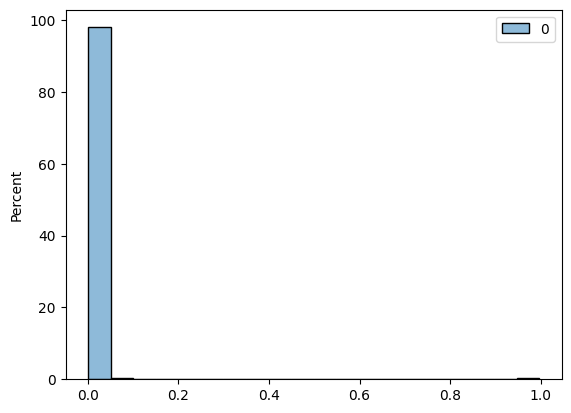

In [14]:
# sns.histplot(predict_signal_intensity_2(x_batch_SP), bins=np.linspace(0, 1, 101), stat="percent")
sns.histplot(predict_signal_intensity_2(x_batch_SP), bins=20, stat="percent")

In [15]:
model.repertoire_label_prediction_layer.weight

Parameter containing:
tensor([[ 1.0313,  1.1862,  1.1253, -1.4322, -1.1773, -1.4619, -1.1346, -1.2061,
         -1.2431,  1.1929]], device='cuda:0', requires_grad=True)

In [16]:
model._compute_signal_topic_weights(repertoire_labels_R=repertoire_labels, label_of_interest=1)

tensor([-0.1202, -0.2138, -0.2090, -0.0581, -0.0638,  0.0365, -0.0382,  0.0344,
         0.1239,  0.1021], device='cuda:0', grad_fn=<MulBackward0>)

In [15]:
# qs = [1 - x for x in (0, 5e-5, 1e-4, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 3e-1, q_l1, 4e-1)]
# qs = [1 - q_l1 + x.item() for x in np.linspace(-0.04, 0.04, 41)]
# qs = [1 - q_l1 + x.item() for x in np.linspace(-0.25, 0.25, 41)]
signal_intensities_by_repertoire_train = []
for sd in tqdm(sequences_datasets_train):
    batch_size = 4096 * 4
    signal_intensities = []
    for batch_start in range(0, sd.size(), batch_size):
        signal_intensities_batch = predict_signal_intensity_2(
            sd.data[batch_start:batch_start+batch_size].to(device)
        ).to("cpu").detach()
        # signal_intensities_batch = model.predict_signal_intensity(
        #     sd.data[batch_start:batch_start+batch_size].to(device), repertoire_labels_R=repertoire_labels
        # ).to("cpu").detach()
        # signal_intensities_batch = _get_topic_strength(
        #     sd.data[batch_start:batch_start+batch_size].to(device), topic_id=1
        # )
        signal_intensities.append(signal_intensities_batch)
    signal_intensities = torch.concatenate(signal_intensities)
    signal_intensities_by_repertoire_train.append(signal_intensities)
# quantiles = [torch.quantile(signal_intensities, q=q).item() for q in qs] + [signal_intensities.mean().item()]
# quantiles_train.append(quantiles)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [02:13<00:00,  1.91it/s]


In [16]:
signal_intensities_by_repertoire_val = []
for sd in tqdm(sequences_datasets_val):
    batch_size = 4096 * 4
    signal_intensities = []
    for batch_start in range(0, sd.size(), batch_size):
        signal_intensities_batch = predict_signal_intensity_2(
            sd.data[batch_start:batch_start+batch_size].to(device)
        ).to("cpu").detach()
        # signal_intensities_batch = model.predict_signal_intensity(
        #     sd.data[batch_start:batch_start+batch_size].to(device), repertoire_labels_R=repertoire_labels
        # ).to("cpu").detach()
        # signal_intensities_batch = _get_topic_strength(
        #     sd.data[batch_start:batch_start+batch_size].to(device), topic_id=1
        # )
        signal_intensities.append(signal_intensities_batch)
    signal_intensities = torch.concatenate(signal_intensities)
    signal_intensities_by_repertoire_val.append(signal_intensities)
# quantiles = [torch.quantile(signal_intensities, q=q).item() for q in qs] + [signal_intensities.mean().item()]
# quantiles_val.append(quantiles)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [00:15<00:00, 17.05it/s]


In [17]:
# qs = [1 - x for x in (0, 1e-5, 2e-5, 5e-5, 1e-4, 1 / n_sequences_per_repertoire_in_batch, 2e-4, 5e-4, 1e-3, 2e-3, 5e-3, 1e-2, 2e-2, 5e-2, 1e-1, 2e-1, 3e-1, 4e-1, 0.42, 0.43, 0.44, 0.45, 0.46, 0.48, 0.49, 0.50, 0.51, 0.52, 0.53, 0.54, 0.55, 0.56, 0.57, 0.58, 0.59, 0.60)]
# qs = [1 - q_l1 + x.item() for x in np.linspace(-0.01, 0.01, 41)]
# qs = [1 - q_l1 + x.item() for x in np.linspace(-0.1, 0.1, 41)]
qs = [1 - q_l1 + x.item() for x in np.linspace(-0.01, 0.01, 41)]
quantiles_train = [
    torch.quantile(signal_intensities, q=torch.tensor(qs)).detach().numpy().tolist() + [signal_intensities.mean().item()]
    for signal_intensities in signal_intensities_by_repertoire_train
]
# quantiles_train.append(quantiles)


In [18]:
quantiles_val = [
    torch.quantile(signal_intensities, q=torch.tensor(qs)).detach().numpy().tolist() + [signal_intensities.mean().item()]
    for signal_intensities in signal_intensities_by_repertoire_val
]

In [19]:
df = pd.DataFrame()
for i, q in enumerate(qs):
    df[str(q)] = [t[i] for t in quantiles_train]
df["mean"] = [t[-1] for t in quantiles_train]
df["label"] = repertoire_labels
df_long = pd.melt(df, id_vars=["label"], value_vars=[str(q) for q in qs] + ["mean"], var_name="q", value_name="signal_intensity")

In [20]:
df_val = pd.DataFrame()
for i, q in enumerate(qs):
    df_val[str(q)] = [t[i] for t in quantiles_val]
df_val["mean"] = [t[-1] for t in quantiles_val]
df_val["label"] = repertoire_labels
df_val_long = pd.melt(df_val, id_vars=["label"], value_vars=[str(q) for q in qs] + ["mean"], var_name="q", value_name="signal_intensity")

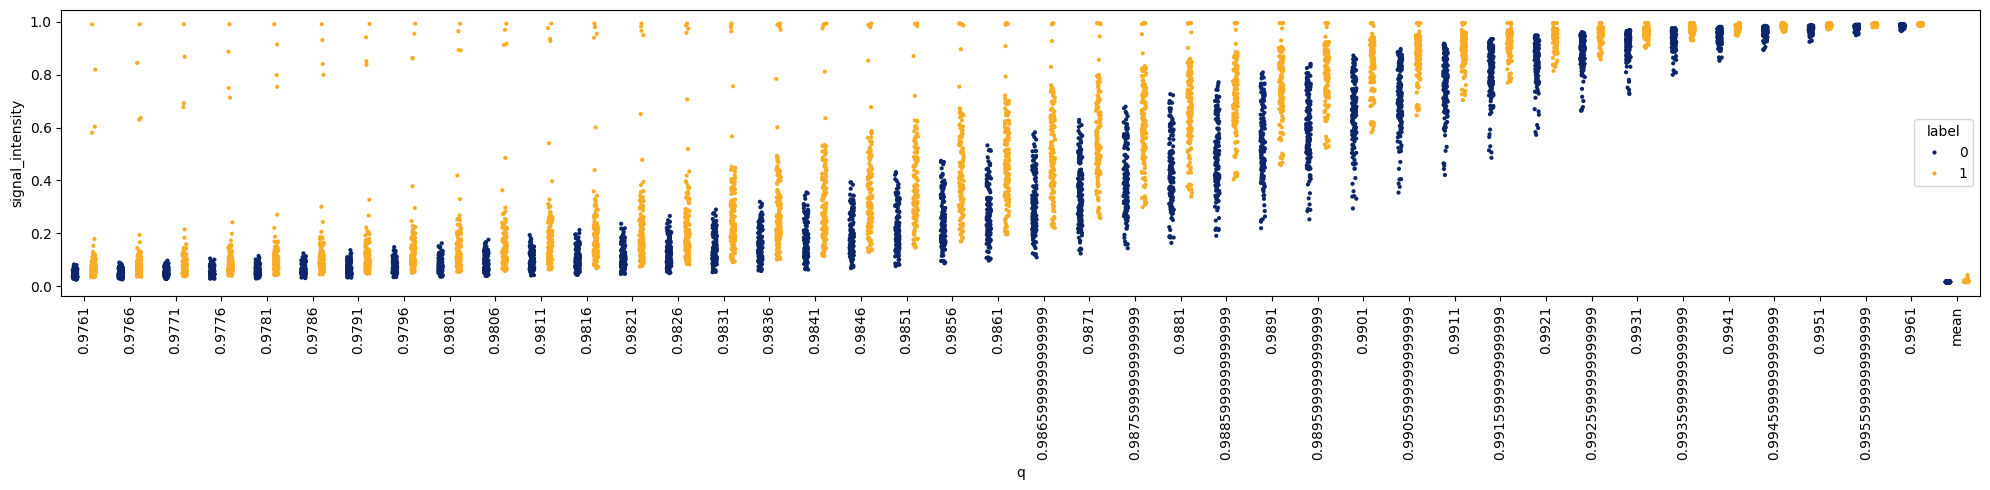

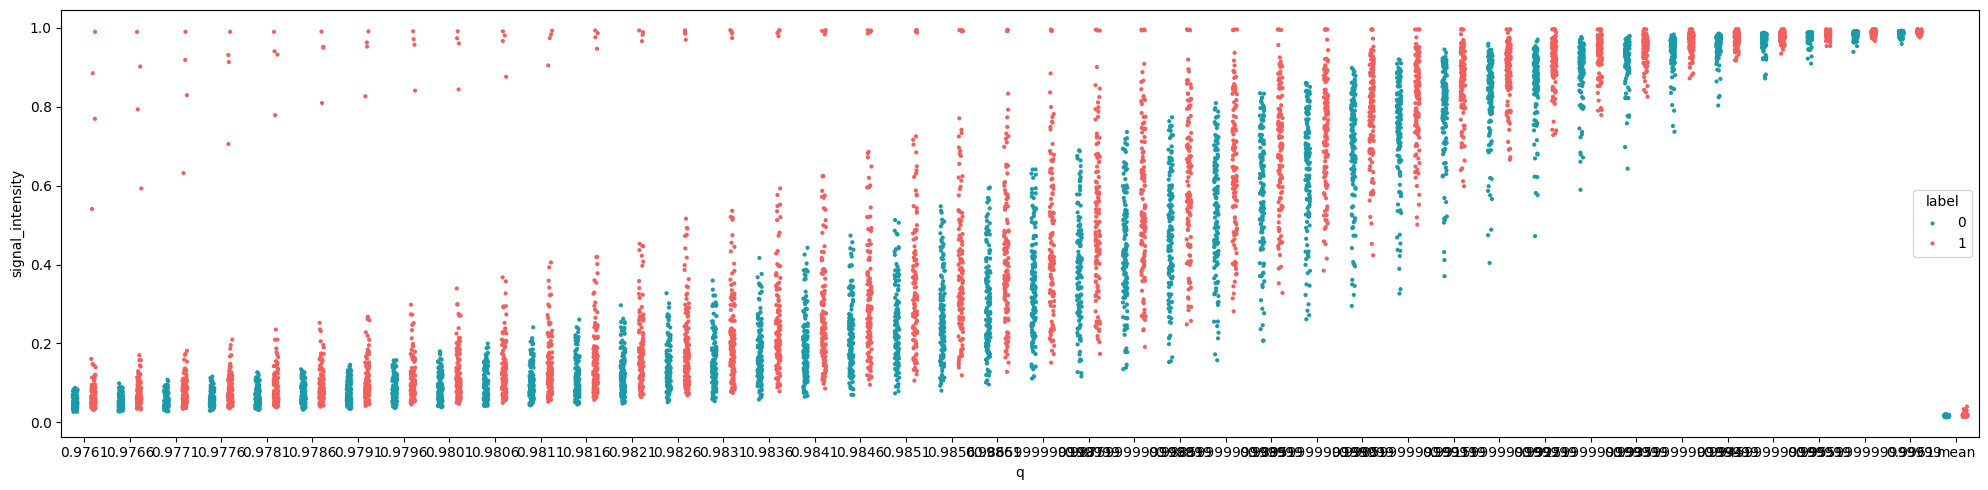

In [21]:
color_1 = "#0C256B"
color_2 = "#FAAC25"
color_3 = "#1B9AAA"
color_4 = "#F25F5C"

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 5))

sns.stripplot(
    data=df_long,
    # data=df_long.loc[df_long["q"] == "mean"],
    x="q",
    y="signal_intensity",
    hue="label",
    palette=[color_1, color_2],
    dodge=True,
    s=3,
    ax=ax,
)
# ax.set_yscale("log")
ax.tick_params(axis="x", rotation=90)
fig.tight_layout()
fig.show()


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 5))

sns.stripplot(
    data=df_val_long,
    # data=df_val_long.loc[df_val_long["q"] == "mean"],
    x="q",
    y="signal_intensity",
    hue="label",
    palette=[color_3, color_4],
    dodge=True,
    s=3,
    ax=ax,
)
# ax.set_yscale("log")


fig.tight_layout()
fig.show()

/tmp/ipykernel_3845498/2795341589.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(len(qs) + 1))
/tmp/ipykernel_3845498/2795341589.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(len(qs) + 1))


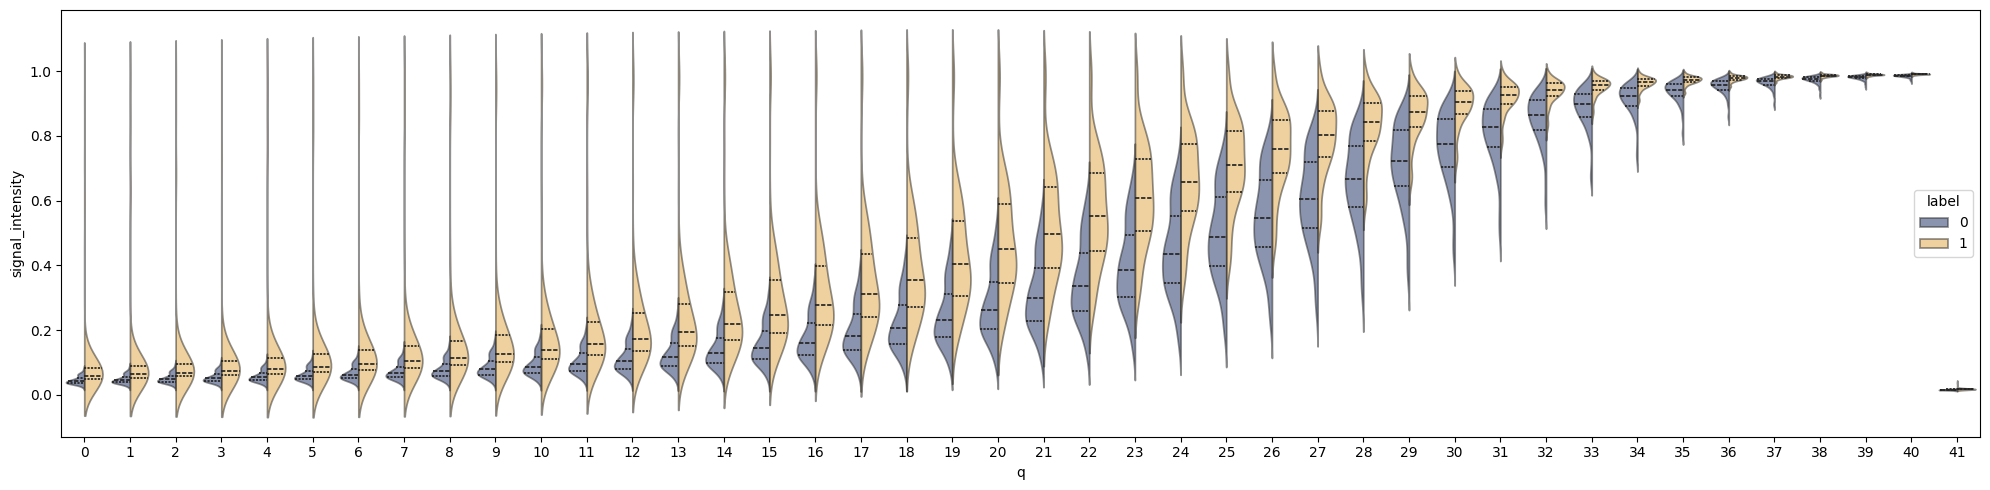

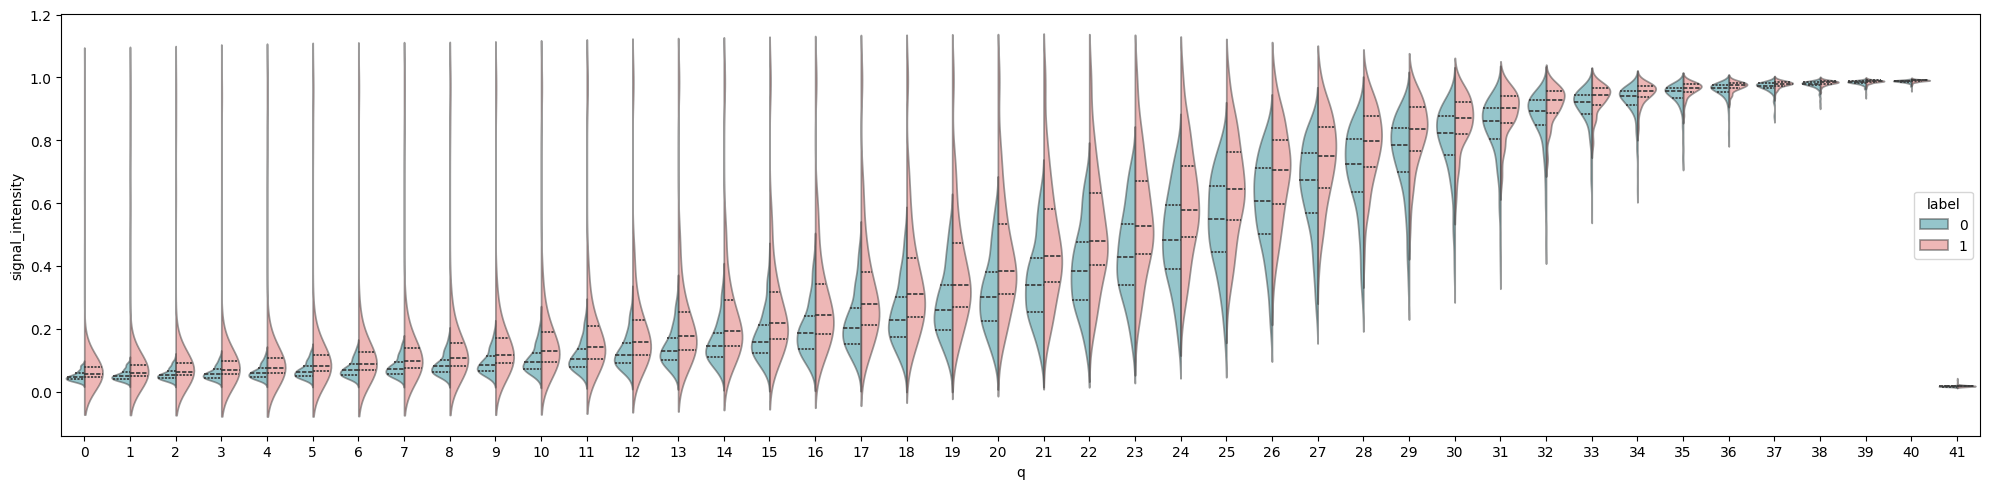

In [22]:
color_1 = "#0C256B"
color_2 = "#FAAC25"
color_3 = "#1B9AAA"
color_4 = "#F25F5C"

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 5))

sns.violinplot(
    data=df_long,
    # data=df_long.loc[df_long["q"].isin([str(q) for q in qs[16:26]])],
    x="q",
    y="signal_intensity",
    hue="label",
    palette=[color_1, color_2],
    dodge=True,
    # s=3,
    ax=ax,
    density_norm="count",
    split=True,
    inner="quart",
    alpha=0.5,
)
# ax.set_xticks([])
ax.set_xticklabels(np.arange(len(qs) + 1))
# ax.set_yscale("log")

fig.tight_layout()
fig.show()


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 5))

sns.violinplot(
    data=df_val_long,
    # data=df_long.loc[df_long["q"].isin([str(q) for q in qs[16:26]])],
    x="q",
    y="signal_intensity",
    hue="label",
    palette=[color_3, color_4],
    dodge=True,
    # s=3,
    ax=ax,
    density_norm="count",
    split=True,
    inner="quart",
    alpha=0.5,
)
ax.set_xticklabels(np.arange(len(qs) + 1))
# ax.set_yscale("log")


fig.tight_layout()
fig.show()

/tmp/ipykernel_2996906/2795341589.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(len(qs) + 1))
/tmp/ipykernel_2996906/2795341589.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(len(qs) + 1))


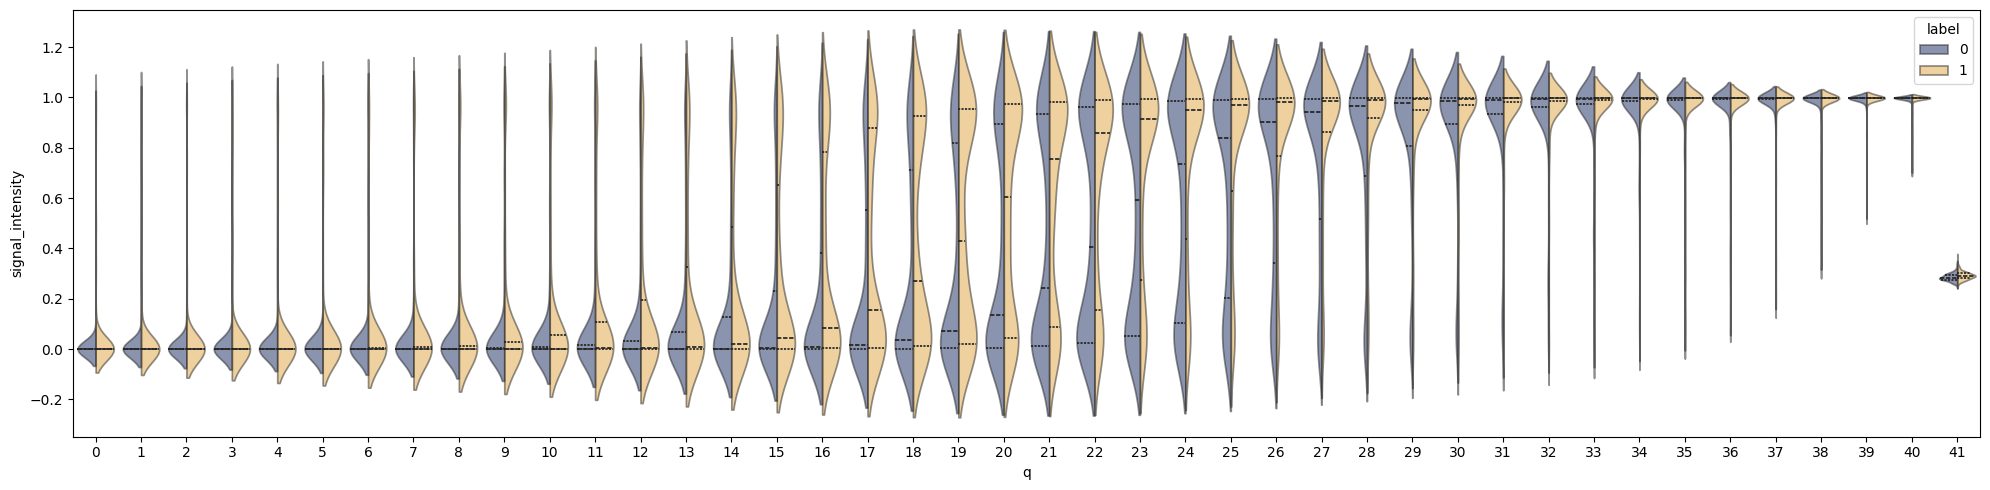

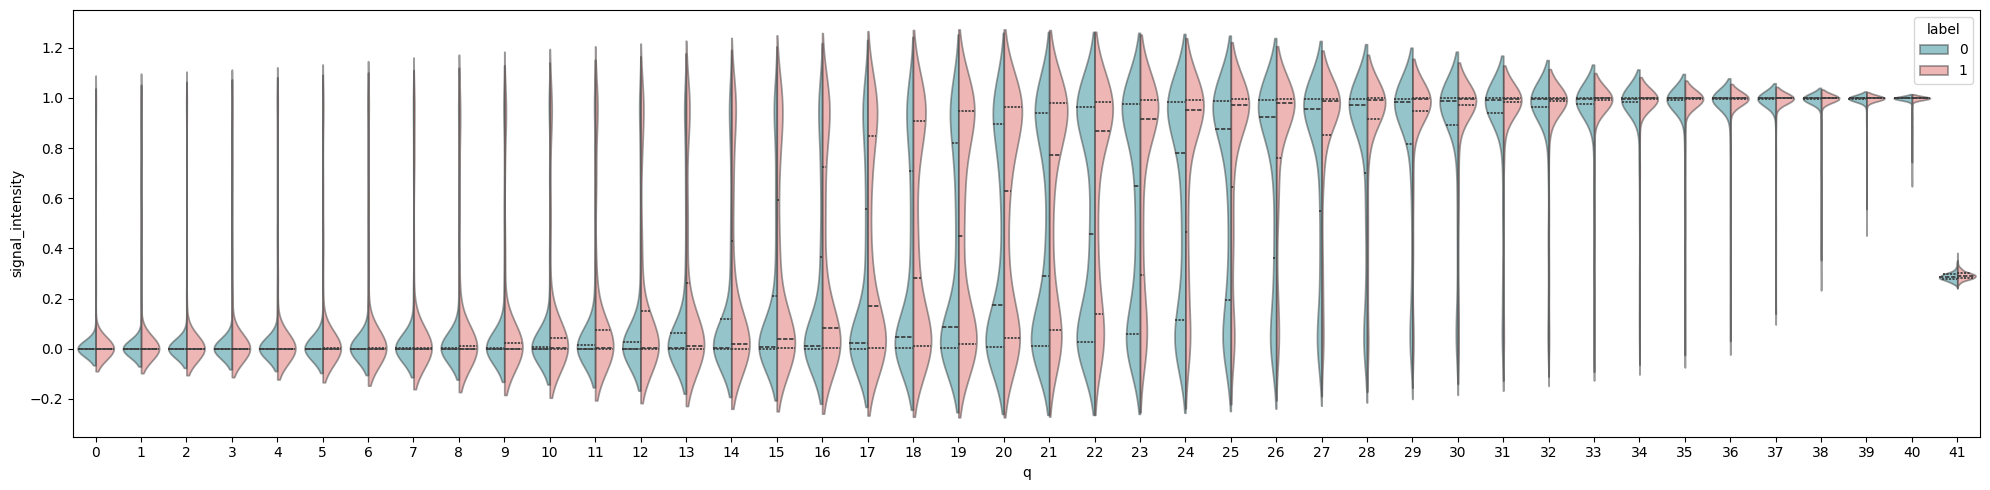

/tmp/ipykernel_3845498/3718588339.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(len(qs) + 1))
/tmp/ipykernel_3845498/3718588339.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(np.arange(len(qs) + 1))


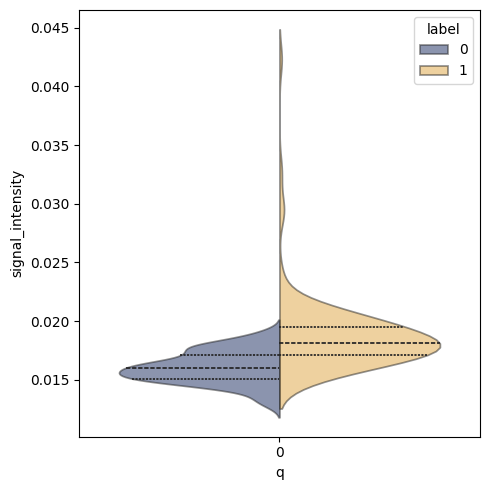

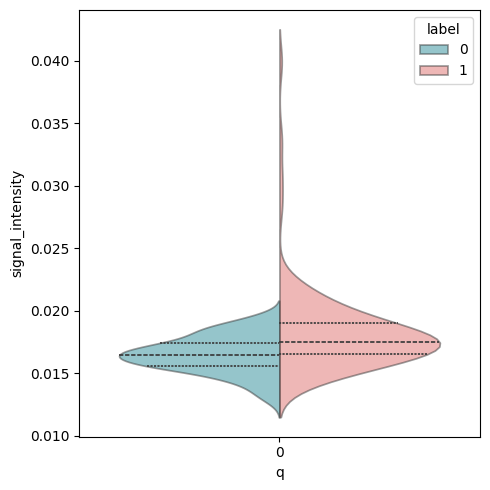

In [23]:
color_1 = "#0C256B"
color_2 = "#FAAC25"
color_3 = "#1B9AAA"
color_4 = "#F25F5C"

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

sns.violinplot(
    # data=df_long,
    data=df_long.loc[df_long["q"] == "mean"],
    x="q",
    y="signal_intensity",
    hue="label",
    palette=[color_1, color_2],
    dodge=True,
    # s=3,
    ax=ax,
    density_norm="width",
    split=True,
    inner="quart",
    alpha=0.5,
)
# ax.set_xticks([])
ax.set_xticklabels(np.arange(len(qs) + 1))
# ax.set_yscale("log")

fig.tight_layout()
fig.show()


fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5, 5))

sns.violinplot(
    # data=df_val_long,
    data=df_val_long.loc[df_val_long["q"] == "mean"],
    x="q",
    y="signal_intensity",
    hue="label",
    palette=[color_3, color_4],
    dodge=True,
    # s=3,
    ax=ax,
    density_norm="width",
    split=True,
    inner="quart",
    alpha=0.5,
)
ax.set_xticklabels(np.arange(len(qs) + 1))
# ax.set_yscale("log")


fig.tight_layout()
fig.show()

In [8]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

In [9]:
clf = RandomForestClassifier(max_depth=1, n_estimators=1000)#, max_features=None)
# clf.fit(np.array(quantiles_train)[:, 8:21], repertoire_labels)
clf.fit(np.array(quantiles_train), repertoire_labels)

NameError: name 'quantiles_train' is not defined

In [10]:
# (clf.predict(np.array(quantiles_train)[:, 8:21]) == repertoire_labels).float().mean()
(clf.predict(np.array(quantiles_train)) == repertoire_labels).float().mean()

NameError: name 'quantiles_train' is not defined

In [29]:
# (clf.predict(np.array(quantiles_val)[:, 8:21) == repertoire_labels).float().mean()
(clf.predict(np.array(quantiles_val)) == repertoire_labels).float().mean()

tensor(0.6445)

In [45]:
t = 0.6
k = 26
((np.array(quantiles_train)[:, k] > t) == repertoire_labels).float().mean(), ((np.array(quantiles_val)[:, k] > t) == repertoire_labels).float().mean()

(tensor(0.5742), tensor(0.5586))

In [287]:
repertoire_labels.float().mean()

tensor(0.4422)

In [293]:
sorted(set(y_pred))[140] 

np.float64(0.5129997730255127)

In [294]:
precisions[140]

0.48796498905907987

In [295]:
recalls[140]

0.8446969696969664

/tmp/ipykernel_1128737/2936855269.py:25: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))


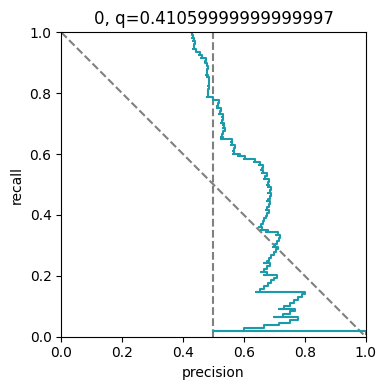

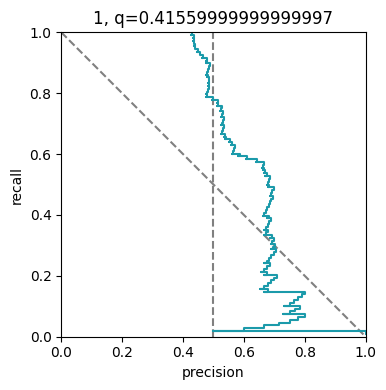

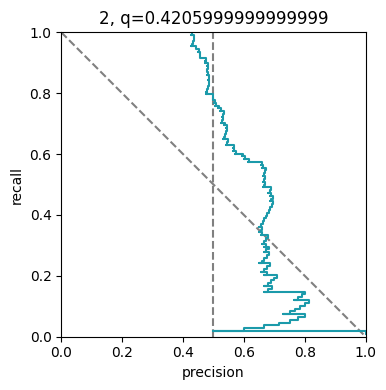

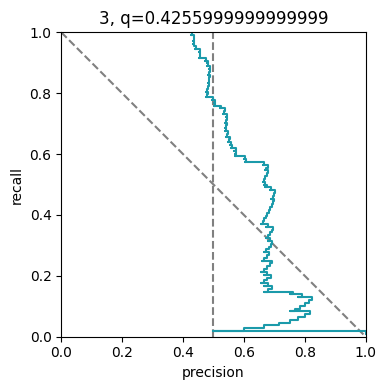

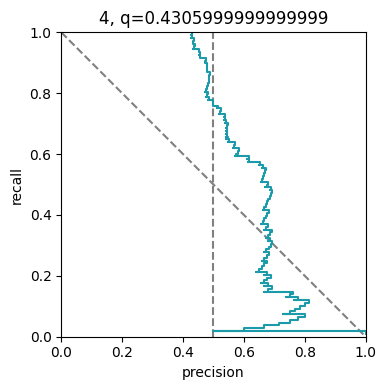

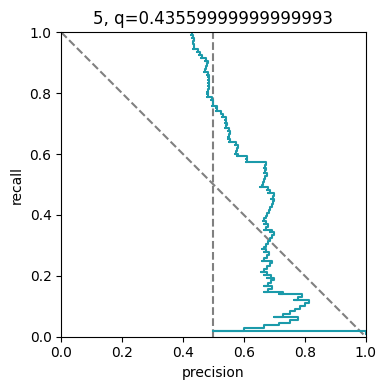

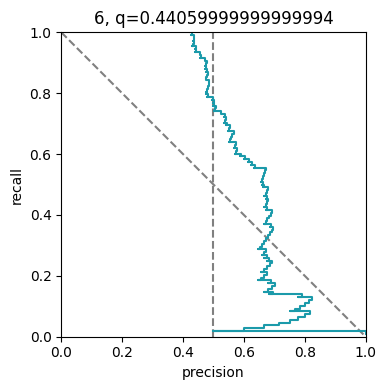

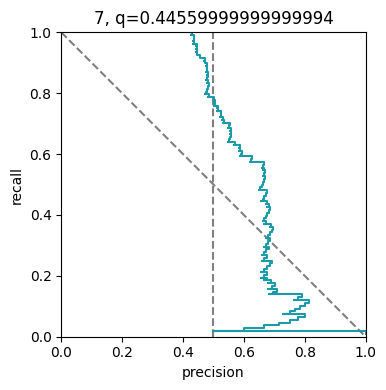

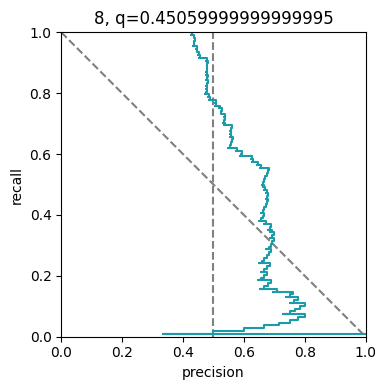

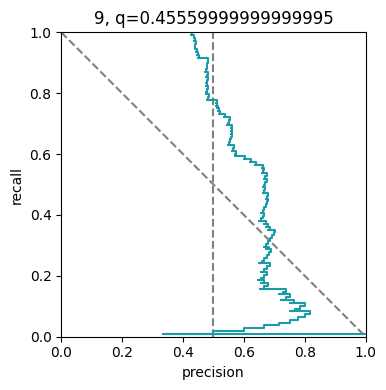

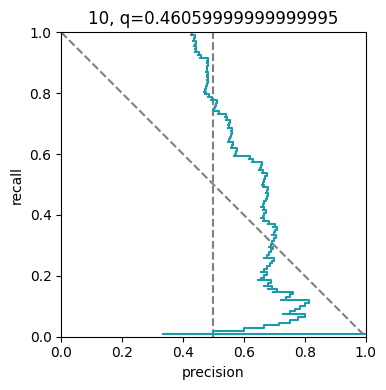

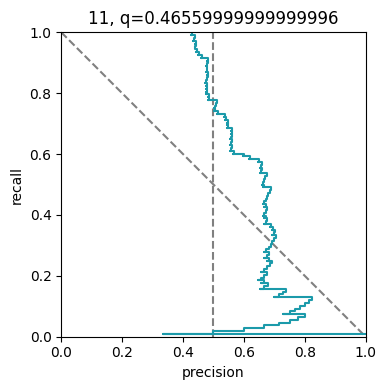

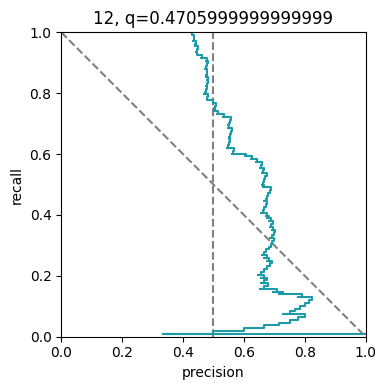

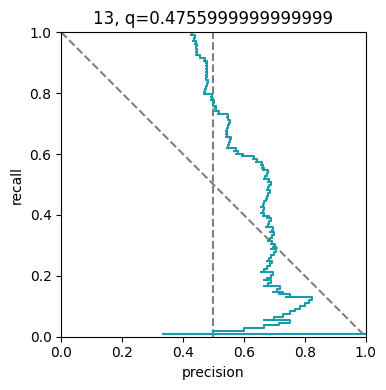

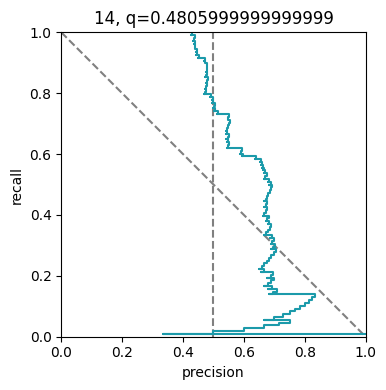

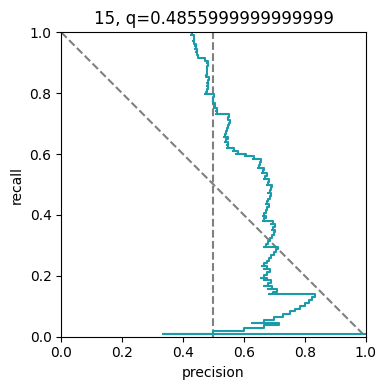

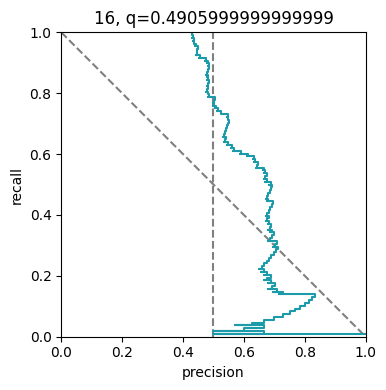

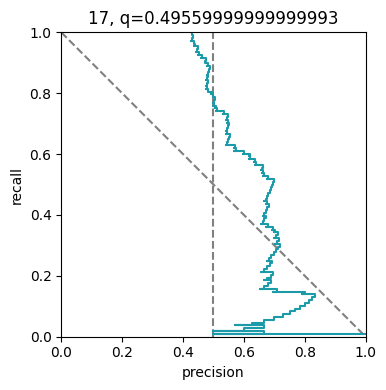

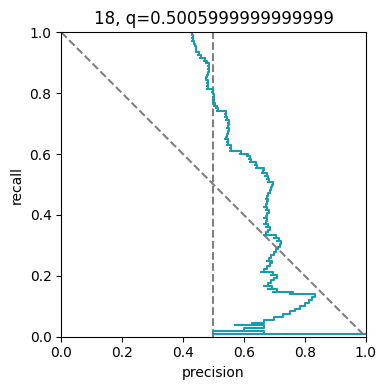

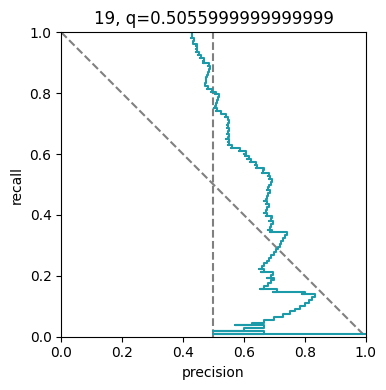

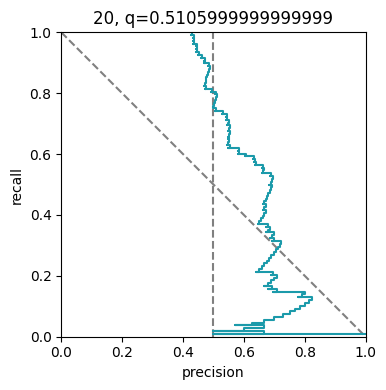

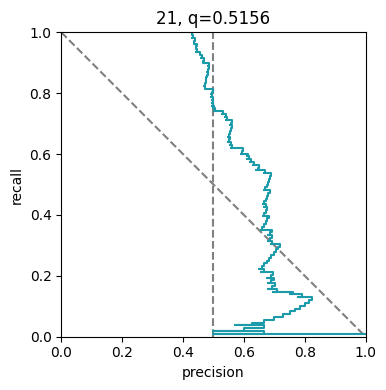

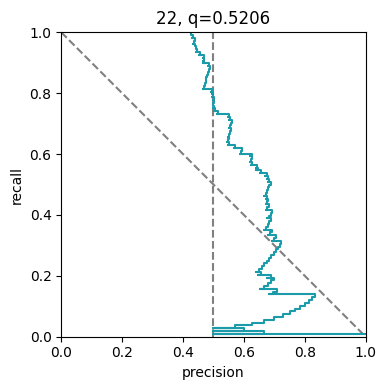

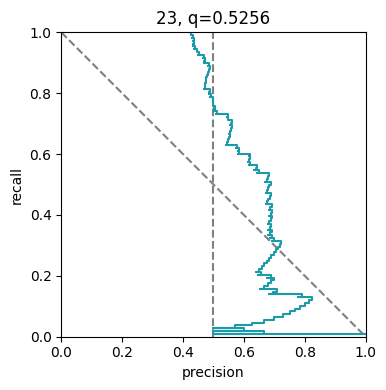

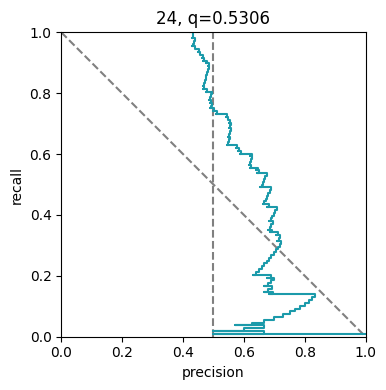

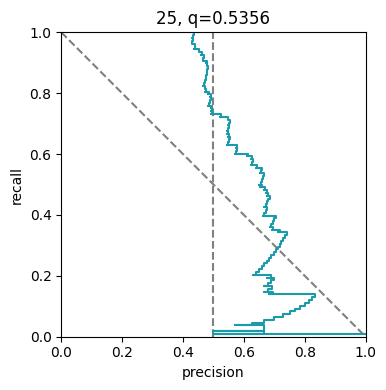

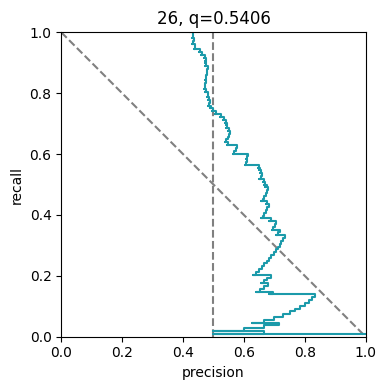

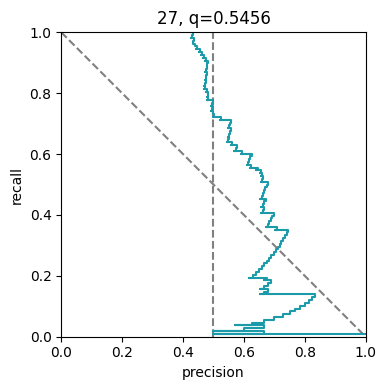

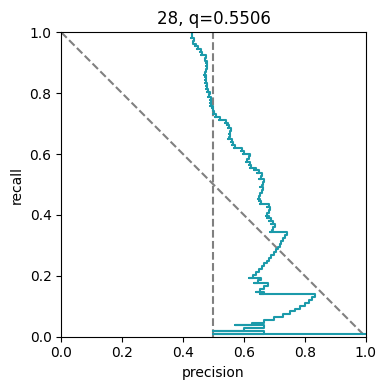

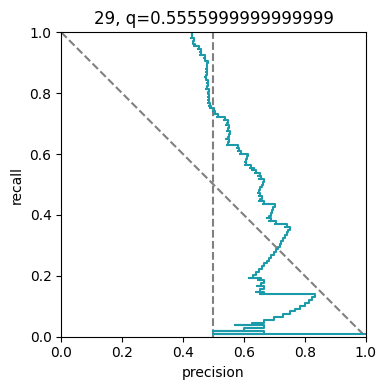

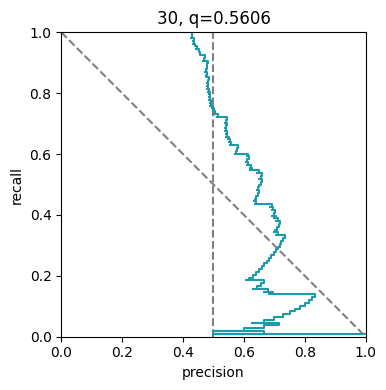

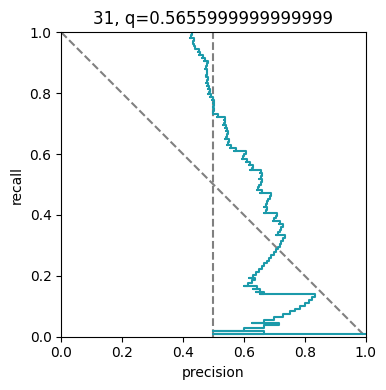

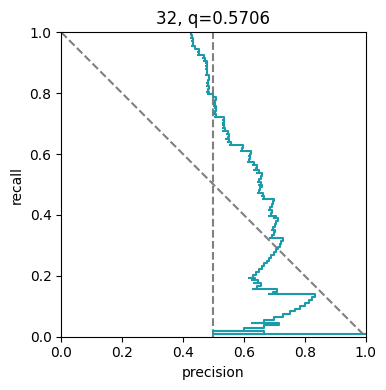

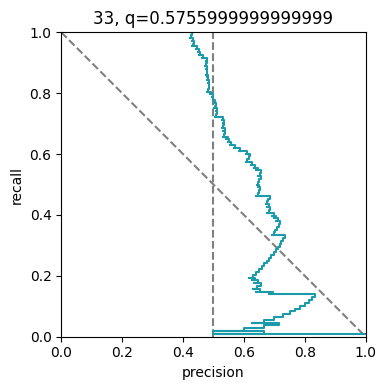

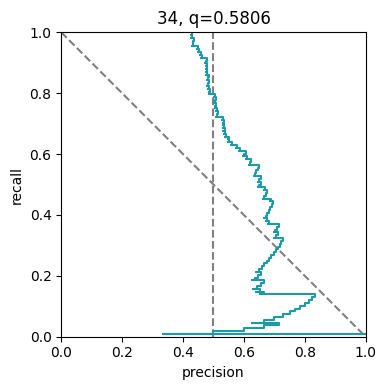

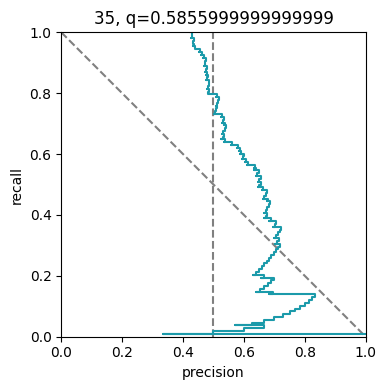

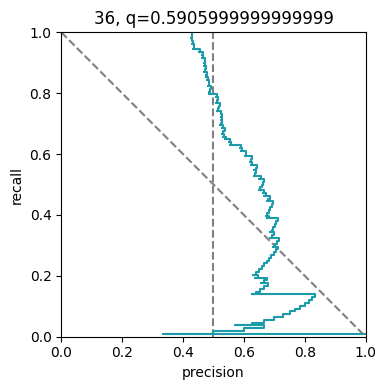

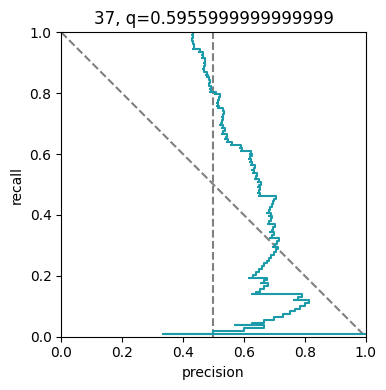

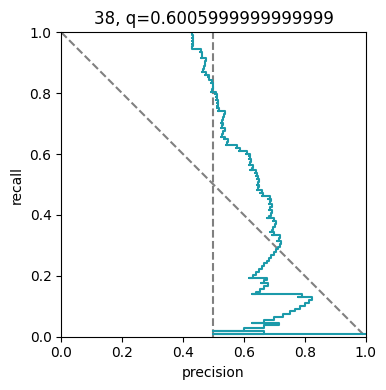

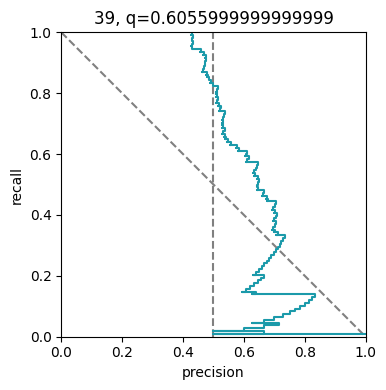

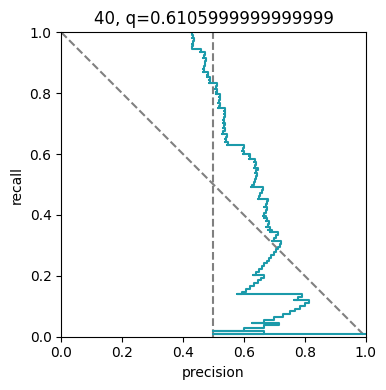

In [25]:
eps = 1e-12

for k in range(len(quantiles_train[0]) - 1):
# for k in [len(quantiles_train[0]) - 1]:
    y_pred = np.array(quantiles_val)[:, k]
    precisions = []
    recalls = []
    
    for t in sorted(set(y_pred)):
    
        y_pred_binary = y_pred >= t
        TP = ((y_pred_binary == 1) & (repertoire_labels.numpy() == 1)).sum()
        P = (repertoire_labels.numpy() == 1).sum()
        PP = (y_pred_binary == 1).sum()
        precision = TP / (PP + eps)
        recall = TP / (P + eps)
        precisions.append(precision.item())
        recalls.append(recall.item())
    

    # pr_pairs = sorted(zip(precisions, recalls))
    # precisions = [p for p, r in pr_pairs]
    # recalls = [r for p, r in pr_pairs]
    
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
    
    
    
    ax.axvline(0.5, color="grey", linestyle="--")
    ax.plot([0, 1], [1, 0], color="grey", linestyle="--")
    
    ax.plot(np.repeat(precisions, 2)[:-1], np.repeat(recalls, 2)[1:], color=color_3)
    # ax.set_yscale("log")
    
    ax.set_xlim((0, 1))
    ax.set_ylim((0, 1))
    
    ax.set_xlabel("precision")
    ax.set_ylabel("recall")

    
    ax.set_title(f"{k}, q={qs[k]}")
    
    ax.set_aspect("equal")
    fig.tight_layout()
    fig.show()



# precision, recall, 2 * precision * recall / (precision + recall)



# xx_pos = np.array(quantiles_val)[:, k][repertoire_labels == 1]
# xx_neg = np.array(quantiles_val)[:, k][repertoire_labels == 0]
# repertoire_labels[xx < t].float().mean()# == repertoire_labels

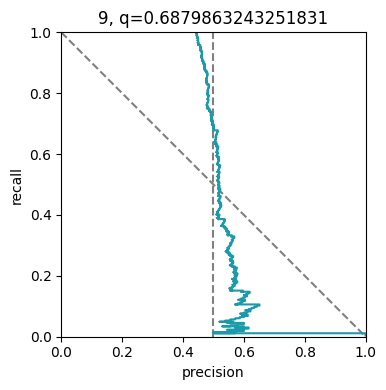

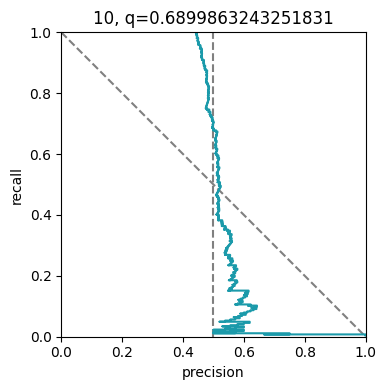

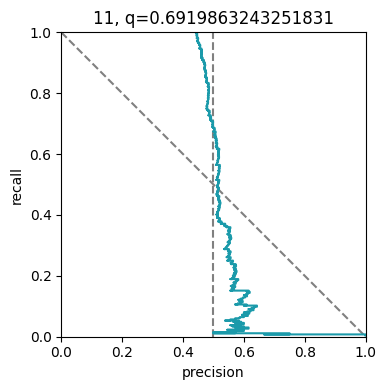

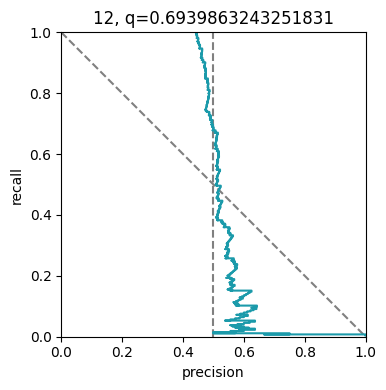

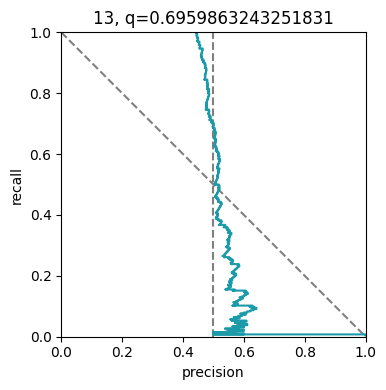

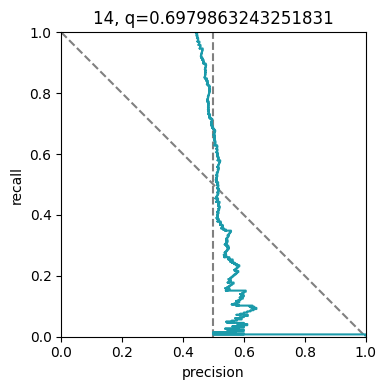

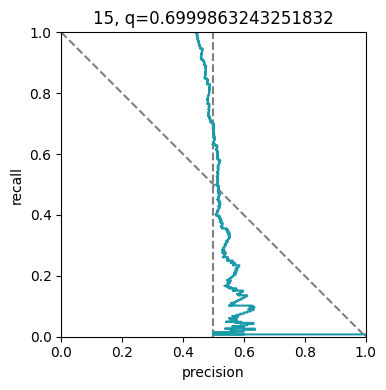

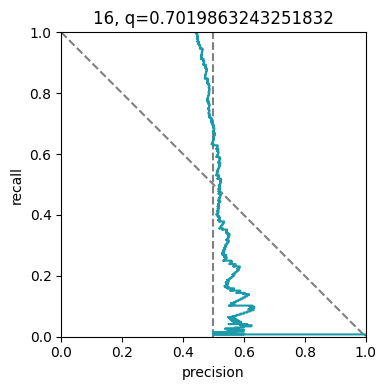

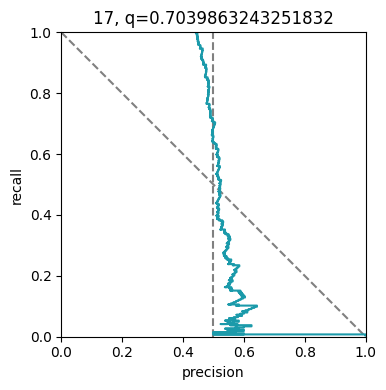

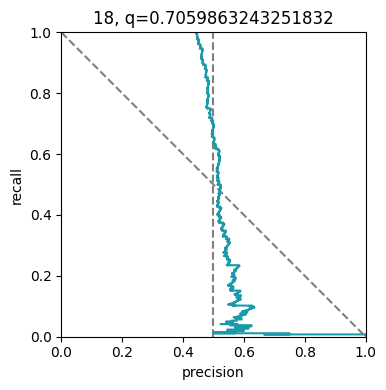

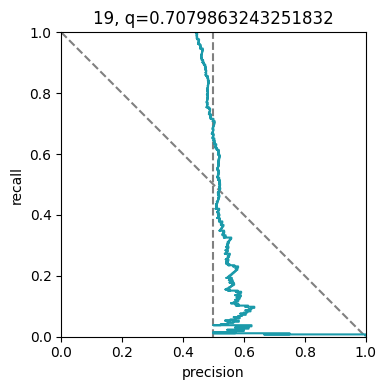

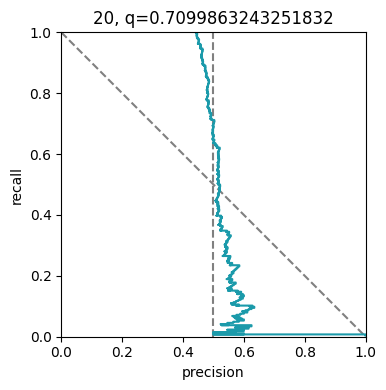

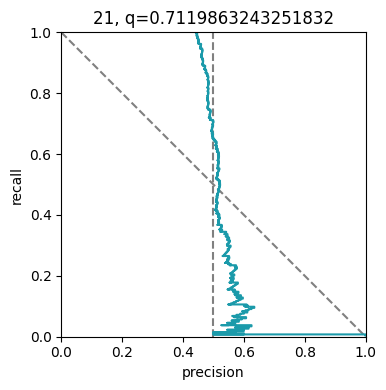

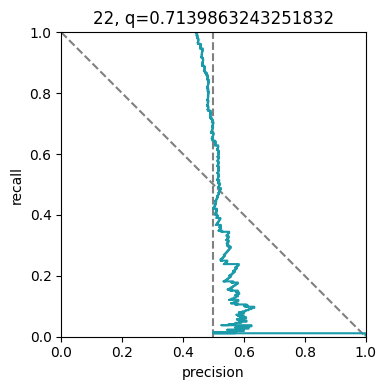

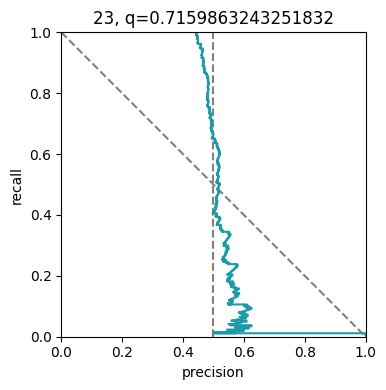

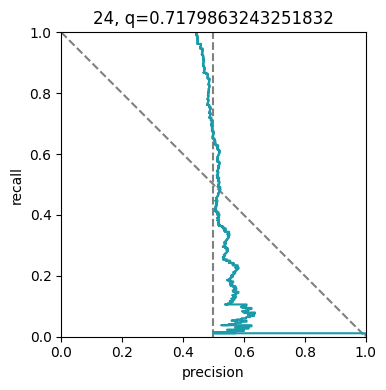

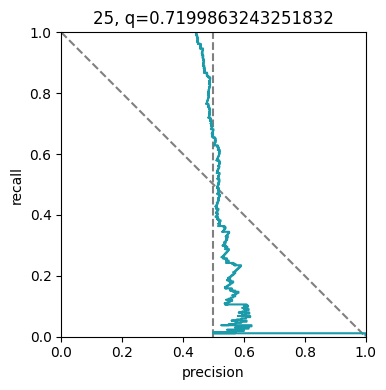

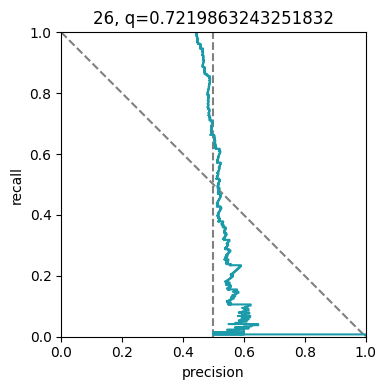

In [277]:
eps = 1e-12

for k in range(9, 27):
    y_pred = np.array(quantiles_val)[:, k]
    precisions = []
    recalls = []
    
    for t in sorted(set(y_pred)):
    
        y_pred_binary = y_pred >= t
        TP = ((y_pred_binary == 1) & (repertoire_labels.numpy() == 1)).sum()
        P = (repertoire_labels.numpy() == 1).sum()
        PP = (y_pred_binary == 1).sum()
        precision = TP / (PP + eps)
        recall = TP / (P + eps)
        precisions.append(precision.item())
        recalls.append(recall.item())
    

    # pr_pairs = sorted(zip(precisions, recalls))
    # precisions = [p for p, r in pr_pairs]
    # recalls = [r for p, r in pr_pairs]
    
    fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(4, 4))
    
    
    
    ax.axvline(0.5, color="grey", linestyle="--")
    ax.plot([0, 1], [1, 0], color="grey", linestyle="--")
    
    ax.plot(np.repeat(precisions, 2)[:-1], np.repeat(recalls, 2)[1:], color=color_3)
    # ax.set_yscale("log")
    
    ax.set_xlim((0, 1))
    ax.set_ylim((0, 1))
    
    ax.set_xlabel("precision")
    ax.set_ylabel("recall")

    
    ax.set_title(f"{k}, q={qs[k]}")
    
    ax.set_aspect("equal")
    fig.tight_layout()
    fig.show()



# precision, recall, 2 * precision * recall / (precision + recall)



# xx_pos = np.array(quantiles_val)[:, k][repertoire_labels == 1]
# xx_neg = np.array(quantiles_val)[:, k][repertoire_labels == 0]
# repertoire_labels[xx < t].float().mean()# == repertoire_labels

In [176]:
xx_pos.mean()

np.float64(0.6724271097900331)

In [177]:
xx_neg.mean()

np.float64(0.514246472766497)

In [104]:
(np.array(quantiles_train)[:, k] > t) == repertoire_labels

tensor([False, False,  True,  True,  True,  True,  True, False,  True, False,
        False, False,  True, False, False, False,  True, False, False,  True,
        False,  True, False, False,  True, False, False,  True,  True,  True,
        False,  True,  True, False,  True,  True, False,  True,  True, False,
         True,  True, False,  True,  True, False,  True, False,  True, False,
         True, False, False, False,  True,  True,  True,  True, False,  True,
         True, False,  True, False,  True, False, False,  True,  True,  True,
         True,  True,  True,  True,  True, False,  True,  True, False,  True,
         True, False,  True, False, False,  True,  True,  True,  True, False,
        False,  True,  True,  True,  True,  True,  True, False, False,  True,
         True,  True, False,  True,  True,  True,  True,  True, False, False,
         True, False,  True,  True,  True,  True,  True,  True,  True,  True,
         True, False, False,  True, False,  True, False,  True, 

In [99]:
clf.feature_importances_

array([1.])

In [90]:
1 == True

True

In [52]:
clf.feature_importances_

array([0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   , 0.   ,
       0.   , 0.14 , 0.184, 0.196, 0.254, 0.226])

In [27]:
clf.predict(np.array(quantiles_val))

array([0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,

In [11]:
signal_intensities.shape

torch.Size([251847])

In [16]:
repertoire_labels

tensor([1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
        0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
        1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [59]:
repertoire_labels

tensor([1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1,
        0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1,
        0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0,
        0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0,
        1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
        0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1,
        0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0,
        0, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0,
        0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0,
        1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,

In [57]:
l = model.sequence_to_latent(x_batch_SP)
(torch.argmax(model.decoder(l), dim=2) == x_batch_SP).float().mean()

tensor(0.9624, device='cuda:0')

In [53]:
torch.nn.functional.softmax(model.decoder(l[:1])[:1], dim=2)

tensor([[[0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.1146, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.1146, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.1146, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.1146, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.0422,
          0.0422, 0.0422, 0.0422, 0.0422, 0.0422, 0.1146, 0.0422, 0.0422,
          0.0422, 0.0422

In [42]:
torch.nn.functional.softmax(model.decoder(l), dim=2)

tensor([[[0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         ...,
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.1146],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.1146],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.1146]],

        [[0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         ...,
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.1146],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.1146],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.1146]],

        [[0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.0422],
         [0.0422, 0.0422, 0.0422,  ..., 0.0422, 0.0422, 0.

In [ ]:
model.sequence_to_latent(x_batch_SP)

In [ ]:
model()

In [17]:
(torch.argmax(self_predictions['decoded_sequences'], dim=2) == x_batch_SP).float().mean()

tensor(0.0214, device='cuda:0')

In [20]:
with torch.no_grad():
    print(criterion(self_predictions, self_targets))

{'total_loss': tensor(1.5292, device='cuda:0'), 'reconstruction_accuracy': tensor(0.6700, device='cuda:0'), 'kl_divergence': tensor(5.3490, device='cuda:0'), 'tm_loss': tensor(0.0014, device='cuda:0'), 'label_accuracy': tensor(0.5578, device='cuda:0')}


In [26]:
-(torch.log(self_predictions['tm_likelihoods']) * sequence_repertoire_indicators + \
 torch.log(1 - self_predictions['tm_likelihoods']) * (1 - sequence_repertoire_indicators)).mean()

tensor(0.0014, device='cuda:0', grad_fn=<NegBackward0>)

In [27]:
-(torch.log(other_predictions['tm_likelihoods']) * (1 - sequence_repertoire_indicators) + \
 torch.log(1 - other_predictions['tm_likelihoods']) * (sequence_repertoire_indicators)).mean()

tensor(6.7949, device='cuda:0', grad_fn=<NegBackward0>)

In [28]:
other_loss

{'total_loss': tensor(4.8922, device='cuda:0', grad_fn=<AddBackward0>),
 'reconstruction_accuracy': tensor(0.6697, device='cuda:0'),
 'kl_divergence': tensor(5.3657, device='cuda:0', grad_fn=<MeanBackward0>),
 'tm_loss': tensor(6.7949, device='cuda:0', grad_fn=<NegBackward0>),
 'label_accuracy': tensor(0.4422, device='cuda:0')}

In [29]:
self_loss

{'total_loss': tensor(1.5292, device='cuda:0', grad_fn=<AddBackward0>),
 'reconstruction_accuracy': tensor(0.6700, device='cuda:0'),
 'kl_divergence': tensor(5.3490, device='cuda:0', grad_fn=<MeanBackward0>),
 'tm_loss': tensor(0.0014, device='cuda:0', grad_fn=<NegBackward0>),
 'label_accuracy': tensor(0.5578, device='cuda:0')}

In [13]:
self_predictions["tm_likelihoods"]

tensor([0.9991, 0.9991, 0.9985,  ..., 0.9971, 0.9991, 0.9994], device='cuda:0',
       grad_fn=<SumBackward1>)

In [14]:
other_predictions["tm_likelihoods"]

tensor([0.9993, 0.9996, 0.9992,  ..., 0.9986, 0.9988, 0.9993], device='cuda:0',
       grad_fn=<SumBackward1>)

In [15]:
sequence_repertoire_indicators

tensor([1, 1, 1,  ..., 1, 1, 1], device='cuda:0')

In [16]:
1 - sequence_repertoire_indicators

tensor([0, 0, 0,  ..., 0, 0, 0], device='cuda:0')

In [18]:
self_targets["sequence_repertoire_indicators"]

tensor([1, 1, 1,  ..., 1, 1, 1], device='cuda:0')

In [ ]:
model.reconstruct(x_batch_SP, deterministic=True, temperature=0.0)

In [ ]:
model.reconstruct(x_batch_SP, deterministic=True, temperature=0.0)

In [ ]:
x_batch_SP

In [ ]:
x_batch_SP

In [33]:
model.reconstruct(x_batch_SP)

tensor([[ 5,  5, 11,  ..., 18,  6,  8],
        [ 5,  5, 15,  ...,  6,  8, 17],
        [ 5,  5, 11,  ...,  4,  6,  8],
        ...,
        [ 5,  5, 11,  ..., 10,  4, 12],
        [ 5,  5, 11,  ..., 18,  6,  8],
        [ 5,  5, 17,  ..., 10, 18, 10]], device='cuda:0')

In [ ]:
with torch.no_grad():
    display(criterion.ce_loss(other_predictions['decoded_sequences'].permute(0, 2, 1), x_batch_SP))

In [ ]:
# other_predictions['decoded_sequences']

In [ ]:
(torch.argmax(other_predictions['decoded_sequences'], dim=2) == x_batch_SP)

In [28]:
torch.argmax(other_predictions['decoded_sequences'], dim=2)

tensor([[12,  6,  5,  ..., 21, 21, 21],
        [12,  5,  5,  ..., 21, 21, 21],
        [12,  5,  5,  ..., 21, 21, 21],
        ...,
        [12,  5,  8,  ..., 21, 21, 21],
        [12,  5,  5,  ..., 21, 21, 21],
        [12,  5,  5,  ..., 21, 21, 21]], device='cuda:0')



 90%|█████████████████████████████████████████████████████      | 253/281 [00:21<00:00, 36.04it/s, batch=251, kl_d=3.03, label_acc=3.03, rec_acc=0.965, tm=3.03, total=3.03]

In [15]:
torch.nn.CrossEntropyLoss()(other_predictions['decoded_sequences'].permute(0, 2, 1), x_batch_SP)

tensor(2.5943, device='cuda:0')

In [15]:
torch.argmax(other_predictions['decoded_sequences'], dim=2)

tensor([[21, 21, 21,  ..., 21, 21, 21],
        [21, 21, 21,  ..., 21, 21, 21],
        [21, 21, 21,  ..., 21, 21, 21],
        ...,
        [21, 21, 21,  ..., 21, 21, 21],
        [21, 21, 21,  ..., 21, 21, 21],
        [21, 21, 21,  ..., 21, 21, 21]], device='cuda:0')

In [16]:
(x_batch_SP == 21).to(torch.float).mean()

tensor(0.5192, device='cuda:0')

In [24]:
other_predictions['decoded_sequences']

tensor([[[2.5989e-05, 4.9384e-05, 3.3069e-05,  ..., 4.4348e-05,
          1.6984e-05, 2.1707e-07],
         [3.4209e-05, 6.8436e-05, 4.0693e-05,  ..., 5.8893e-05,
          2.2980e-05, 7.4785e-08],
         [3.3625e-05, 6.7439e-05, 4.1100e-05,  ..., 5.9450e-05,
          2.3383e-05, 6.5875e-08],
         ...,
         [6.0871e-11, 3.4016e-11, 1.0762e-10,  ..., 6.0387e-11,
          1.7119e-11, 1.0000e+00],
         [5.9393e-11, 3.4967e-11, 1.1187e-10,  ..., 6.0369e-11,
          1.6305e-11, 1.0000e+00],
         [3.3356e-11, 1.8263e-11, 5.8997e-11,  ..., 3.5116e-11,
          9.2645e-12, 1.0000e+00]],

        [[2.5253e-05, 4.6327e-05, 3.2127e-05,  ..., 4.2645e-05,
          1.5792e-05, 2.8645e-07],
         [3.3533e-05, 6.5404e-05, 3.9497e-05,  ..., 5.7121e-05,
          2.1538e-05, 9.4364e-08],
         [3.1365e-05, 6.2899e-05, 4.0177e-05,  ..., 5.6767e-05,
          2.1140e-05, 1.0024e-07],
         ...,
         [6.1523e-11, 3.3872e-11, 1.0995e-10,  ..., 6.1375e-11,
          1.732